In [67]:
#set colors 
import matplotlib.pyplot as plt

# ── Theme colors ───────────────────────────────────────────
GES_DARK  = '#01010b'   # black
GES_BLUE  = '#6950ec'   # purple
GES_GOLD  = '#e00e32'   # berry red
GES_TEAL  = '#a3055c'   # maroon

PALETTE = [
    '#6950ec',  # purple
    '#a3055c',  # maroon
    '#e00e32',  # berry red
    '#9e9e9e',  # gray
    '#8a7cff',  # soft purple
    '#c75a93',  # dusty pink
    '#d9d9d9',  # light gray
    '#b23a6f'   # muted berry
]

# ── Global chart settings ──────────────────────────────────
FIGSIZE = (10, 6)
TITLE_SIZE = 14
LABEL_SIZE = 11
TICK_SIZE = 10
BAR_LABEL_SIZE = 9
ROTATION = 20
GRID_ALPHA = 0.35
BAR_ALPHA = 0.9
EDGE_COLOR = '#d9d9d9'

plt.rcParams.update({
    'figure.facecolor':  GES_DARK,
    'axes.facecolor':    '#141420',
    'savefig.facecolor': GES_DARK,
    'axes.edgecolor':    '#444',
    'axes.labelcolor':   'white',
    'xtick.color':       '#ccc',
    'ytick.color':       '#ccc',
    'text.color':        'white',
    'grid.color':        '#333',
    'grid.linestyle':    '--',
    'grid.alpha':        0.5,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

# Additional EDA: Customer Behavior, Journey, and Data Integration Insights

This notebook builds on the merged dataset created in the original exploratory analysis. The goal here is to extend the analysis with new insights that better support the ITC case prompt, rather than repeat work that has already been done.

## 1. Dataset Check

Before starting new analysis, I first verify the structure of the merged dataset. This helps confirm which fields are available for customer-level summaries, transaction sequencing, source visibility, and channel behavior.

In [69]:
import pandas as pd

# load merged dataset
df = pd.read_csv("Data/merged_customer_data.csv")

# basic check
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False))

df.head()

Shape: (2500, 31)

Columns:
['Transaction ID', 'Customer ID', 'Transaction Date', 'Business Line', 'Product/Service', 'Revenue', 'Data Source', 'Region', 'Source Type', 'Primary Business Line', 'Business Lines Engaged', 'Total Transactions', 'Lifetime Value', 'First Interaction', 'Last Interaction', 'Engagement Score', 'Data Completeness %', 'Customer Data Type', 'Email', 'Age Range', 'Gender', 'Source ID', 'Business Line_ds', 'Data Source Name', 'Source Type_ds', 'Customer ID Available', 'Email Available', 'Demographics Available', 'Data Quality', 'Integration Status', 'Notes']

Data types:
Transaction ID             object
Customer ID                object
Transaction Date           object
Business Line              object
Product/Service            object
Revenue                   float64
Data Source                object
Region                     object
Source Type                object
Primary Business Line      object
Business Lines Engaged      int64
Total Transactions         

,Transaction ID,Customer ID,Transaction Date,Business Line,Product/Service,Revenue,Data Source,Region,Source Type,Primary Business Line,...,Source ID,Business Line_ds,Data Source Name,Source Type_ds,Customer ID Available,Email Available,Demographics Available,Data Quality,Integration Status,Notes
0,TXN000001,CUST00150,2024-01-01,Consumer Products,Merchandise - Collectibles,54.06,3rd Party - Walmart,East Coast,3rd Party,Consumer Products,...,8,Consumer Products,3rd Party - Walmart,3rd Party,No,No,No,Low-Medium,Not Integrated,Currently no direct data access; relies on ret...
1,TXN000002,CUST00642,2024-01-01,Consumer Products,Merchandise - Apparel,40.87,3rd Party - Target,West Coast,3rd Party,Consumer Products,...,7,Consumer Products,3rd Party - Target,3rd Party,No,No,No,Low-Medium,Not Integrated,Currently no direct data access; relies on ret...
2,TXN000003,CUST00035,2024-01-01,Streaming,Monthly Subscription,10.72,1st Party - Streaming Platform,Southwest,1st Party,Streaming,...,1,Streaming,1st Party - Streaming Platform,1st Party,Yes,Yes,Yes (80% complete),High,Fully Integrated,Complete customer profiles with viewing history
3,TXN000004,CUST00163,2024-01-02,Theatrical,Mystery Manor,17.24,3rd Party - AMC Theatres,Southwest,3rd Party,Theatrical,...,4,Theatrical,3rd Party - AMC Theatres,3rd Party,Limited (cinema loyalty ID only),No,No,Medium,Limited - Aggregated Data Only,Currently receives only title-level sales data...
4,TXN000005,CUST00185,2024-01-02,Theatrical,Space Odyssey 2,27.81,3rd Party - Cinemark,East Coast,3rd Party,Theatrical,...,6,Theatrical,3rd Party - Cinemark,3rd Party,Limited (cinema loyalty ID only),No,No,Medium,Limited - Aggregated Data Only,Currently receives only title-level sales data...


## 2. First Touchpoint and Channel Progression

The earlier analysis showed which channels tend to co-occur, but co-engagement alone does not explain how customers enter and move through the GES ecosystem.

This section looks at each customer’s first observed business line and whether certain entry points are more likely to lead to multi-channel behavior. That helps shift the analysis from simple overlap to a more directional customer journey view.

In [71]:
# make sure Transaction Date is datetime
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"], errors="coerce")

# sort transactions in time order
df_sorted = df.sort_values(["Customer ID", "Transaction Date"])

# first observed touchpoint for each customer
first_touch = (
    df_sorted.groupby("Customer ID", as_index=False)
    .first()[["Customer ID", "Business Line", "Transaction Date", "Source Type", "Data Source"]]
    .rename(columns={
        "Business Line": "first_business_line",
        "Transaction Date": "first_transaction_date",
        "Source Type": "first_source_type",
        "Data Source": "first_data_source"
    })
)

# how many business lines each customer touched overall
channel_counts = (
    df.groupby("Customer ID")["Business Line"]
    .nunique()
    .reset_index(name="unique_business_lines")
)

# combine first touch with eventual channel breadth
first_touch_summary = first_touch.merge(channel_counts, on="Customer ID", how="left")

# single vs multi-channel outcome
first_touch_summary["final_channel_type"] = first_touch_summary["unique_business_lines"].apply(
    lambda x: "Single-Channel" if x == 1 else "Multi-Channel"
)

first_touch_summary.head()

,Customer ID,first_business_line,first_transaction_date,first_source_type,first_data_source,unique_business_lines,final_channel_type
0,CUST00001,Online Store,2024-03-19,1st Party,1st Party - Online Store,3,Multi-Channel
1,CUST00002,Streaming,2024-01-04,1st Party,1st Party - Streaming Platform,4,Multi-Channel
2,CUST00003,Streaming,2024-03-11,1st Party,1st Party - Streaming Platform,3,Multi-Channel
3,CUST00004,Streaming,2024-02-27,1st Party,1st Party - Streaming Platform,3,Multi-Channel
4,CUST00005,Online Store,2024-03-30,1st Party,1st Party - Online Store,2,Multi-Channel


In [72]:
# distribution of first touchpoints
first_touch_dist = (
    first_touch_summary["first_business_line"]
    .value_counts()
    .reset_index()
)
first_touch_dist.columns = ["First Business Line", "Customer Count"]

first_touch_dist

,First Business Line,Customer Count
0,Theatrical,102
1,Consumer Products,87
2,Online Store,59
3,Streaming,58
4,Studio Tours,57


In [73]:
# among customers entering through each business line,
# how many stayed single-channel vs became multi-channel?
first_touch_progression = pd.crosstab(
    first_touch_summary["first_business_line"],
    first_touch_summary["final_channel_type"],
    normalize="index"
).round(3) * 100

first_touch_progression

final_channel_type,Multi-Channel,Single-Channel
first_business_line,,
Consumer Products,63.2,36.8
Online Store,100.0,0.0
Streaming,98.3,1.7
Studio Tours,100.0,0.0
Theatrical,59.8,40.2


In [74]:
# total revenue per customer
customer_revenue = (
    df.groupby("Customer ID", as_index=False)["Revenue"]
    .sum()
    .rename(columns={"Revenue": "total_customer_revenue"})
)

# merge with first-touch summary
first_touch_value = first_touch_summary.merge(customer_revenue, on="Customer ID", how="left")

# average revenue by first business line
avg_revenue_first_touch = (
    first_touch_value.groupby("first_business_line", as_index=False)["total_customer_revenue"]
    .mean()
    .sort_values("total_customer_revenue", ascending=False)
)

avg_revenue_first_touch

,first_business_line,total_customer_revenue
3,Studio Tours,908.547895
2,Streaming,869.287931
1,Online Store,688.264746
0,Consumer Products,393.416437
4,Theatrical,324.462059


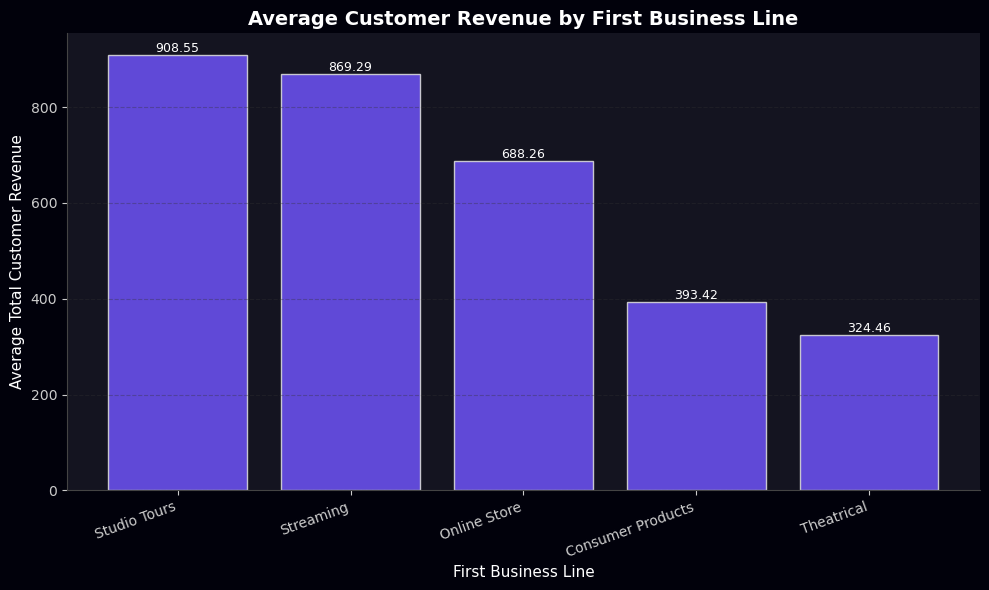

<Figure size 640x480 with 0 Axes>

In [133]:
plt.figure(figsize=FIGSIZE)

bars = plt.bar(
    avg_revenue_first_touch["first_business_line"],
    avg_revenue_first_touch["total_customer_revenue"],
    color=PALETTE[0],
    edgecolor=EDGE_COLOR,
    alpha=BAR_ALPHA
)

plt.title("Average Customer Revenue by First Business Line", fontsize=TITLE_SIZE, weight="bold")
plt.xlabel("First Business Line", fontsize=LABEL_SIZE)
plt.ylabel("Average Total Customer Revenue", fontsize=LABEL_SIZE)
plt.xticks(rotation=ROTATION, ha="right", fontsize=TICK_SIZE)
plt.yticks(fontsize=TICK_SIZE)
plt.grid(axis="y", alpha=GRID_ALPHA)

plt.bar_label(bars, fmt="%.2f", fontsize=BAR_LABEL_SIZE)
plt.tight_layout()
plt.show()

plt.savefig("Visuals/ben_first_touch_average_revenue.png", dpi=300, bbox_inches="tight")

### Insight: Entry channel appears to influence broader customer engagement

This analysis suggests that a customer’s first observed touchpoint may shape how broadly they engage with GES over time. Customers whose first recorded interaction came through **Online Store, Streaming, or Studio Tours** were overwhelmingly likely to later appear across multiple business lines. In contrast, customers entering through **Theatrical** or **Consumer Products** were much more likely to remain single-channel.

This matters because the broader case focuses on identifying and growing high-value **multi-channel customers**. From that perspective, the results suggest that GES’s more direct or owned channels may currently be stronger pathways into wider ecosystem engagement, while **Theatrical** and **Consumer Products** may represent the greatest opportunity for improved conversion into other channels.

These findings are also strategically useful for the proposal. If GES wants to expand customer lifetime value and build a more unified customer view, it should not only strengthen its high-performing entry channels, but also focus on improving how customers from Theatrical and Consumer Products are identified, nurtured, and guided into first-party relationships such as Streaming or Online Store.

At the same time, this result should be interpreted carefully. Lower multi-channel progression from Theatrical or Consumer Products may reflect not only weaker conversion, but also weaker customer visibility, since third-party channels are harder to track at the individual level. For that reason, this analysis supports both a **marketing opportunity** and a **data integration opportunity**: GES may need better cross-channel conversion tactics, better identity resolution, or both.

Customers that entered through **studio tours** and **streaming** brought the most revenue later

## 3. Customer Ecosystem Segments: 1st-Party, 3rd-Party, and Mixed

A major theme of the case is that GES does not have a fully unified view of customers across its first-party and third-party channels. To build on the earlier EDA, this section groups customers based on whether they appear only in first-party sources, only in third-party sources, or in both.

This is useful because these groups likely represent very different business situations. Customers appearing in both ecosystems may already reflect stronger engagement and higher current value, while third-party-only customers may represent the largest opportunity for better identification, conversion, and cross-channel growth.

In [78]:
# source-type presence for each customer
customer_source_presence = (
    df.groupby("Customer ID")["Source Type"]
    .agg(lambda x: sorted(set(x.dropna())))
    .reset_index()
)

# classify ecosystem segment
def classify_ecosystem(source_list):
    source_set = set(source_list)
    if source_set == {"1st Party"}:
        return "1st-Party Only"
    elif source_set == {"3rd Party"}:
        return "3rd-Party Only"
    elif source_set == {"1st Party", "3rd Party"}:
        return "Mixed"
    else:
        return "Unknown"

customer_source_presence["ecosystem_segment"] = customer_source_presence["Source Type"].apply(classify_ecosystem)

customer_source_presence.head()

,Customer ID,Source Type,ecosystem_segment
0,CUST00001,[1st Party],1st-Party Only
1,CUST00002,"[1st Party, 3rd Party]",Mixed
2,CUST00003,[1st Party],1st-Party Only
3,CUST00004,[1st Party],1st-Party Only
4,CUST00005,[1st Party],1st-Party Only


In [79]:
# size of each ecosystem segment
ecosystem_counts = (
    customer_source_presence["ecosystem_segment"]
    .value_counts()
    .reset_index()
)

ecosystem_counts.columns = ["Ecosystem Segment", "Customer Count"]
ecosystem_counts

,Ecosystem Segment,Customer Count
0,Mixed,230
1,3rd-Party Only,114
2,1st-Party Only,19


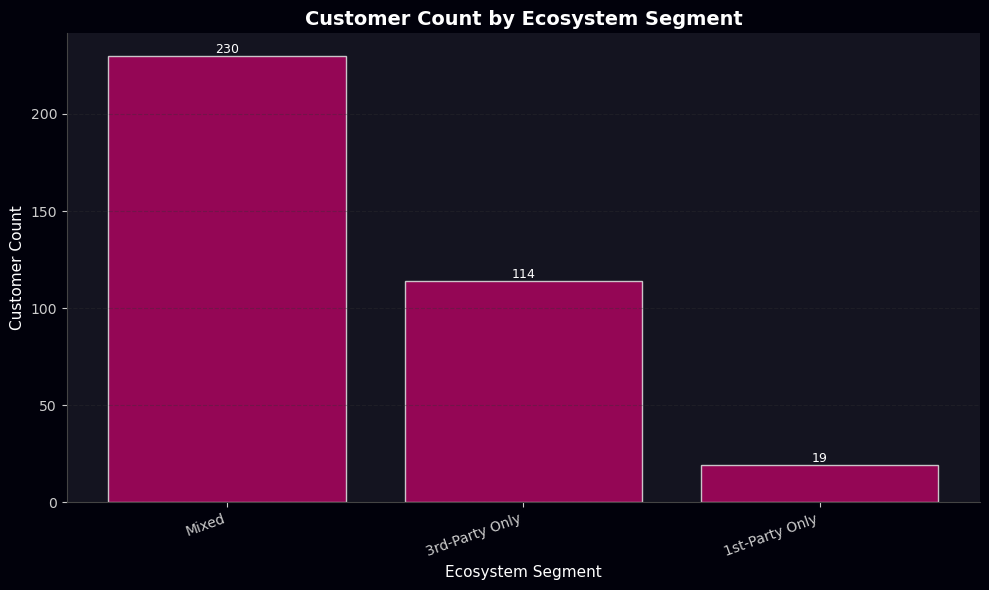

<Figure size 640x480 with 0 Axes>

In [135]:
plt.figure(figsize=FIGSIZE)

bars = plt.bar(
    ecosystem_counts["Ecosystem Segment"],
    ecosystem_counts["Customer Count"],
    color=PALETTE[1],
    edgecolor=EDGE_COLOR,
    alpha=BAR_ALPHA
)

plt.title("Customer Count by Ecosystem Segment", fontsize=TITLE_SIZE, weight="bold")
plt.xlabel("Ecosystem Segment", fontsize=LABEL_SIZE)
plt.ylabel("Customer Count", fontsize=LABEL_SIZE)
plt.xticks(rotation=ROTATION, ha="right", fontsize=TICK_SIZE)
plt.yticks(fontsize=TICK_SIZE)
plt.grid(axis="y", alpha=GRID_ALPHA)

plt.bar_label(bars, fontsize=BAR_LABEL_SIZE)
plt.tight_layout()
plt.show()
plt.savefig("Visuals/ben_customer_count_ecosystem.png", dpi=300, bbox_inches="tight")

In [81]:
# merge ecosystem segment back to customer revenue and channel breadth
customer_metrics = (
    df.groupby("Customer ID")
    .agg(
        total_revenue=("Revenue", "sum"),
        total_transactions=("Transaction ID", "count"),
        unique_business_lines=("Business Line", "nunique")
    )
    .reset_index()
)

ecosystem_summary = (
    customer_source_presence.merge(customer_metrics, on="Customer ID", how="left")
    .groupby("ecosystem_segment", as_index=False)
    .agg(
        customers=("Customer ID", "count"),
        avg_customer_revenue=("total_revenue", "mean"),
        avg_transactions=("total_transactions", "mean"),
        avg_business_lines=("unique_business_lines", "mean")
    )
    .sort_values("avg_customer_revenue", ascending=False)
)

ecosystem_summary

,ecosystem_segment,customers,avg_customer_revenue,avg_transactions,avg_business_lines
2,Mixed,230,829.271304,9.434783,4.269565
0,1st-Party Only,19,598.683158,5.473684,2.684211
1,3rd-Party Only,114,70.425702,1.982456,1.359649


### Insight: Mixed customers appear to be the highest-value segment

Customers observed in both first-party and third-party sources are clearly the strongest segment in the sample. The **Mixed** group has the highest average customer revenue, the most transactions per customer, and the broadest average channel engagement. This suggests that customers connected across both ecosystems are not only more visible to GES, but also more valuable and more deeply engaged.

By contrast, **3rd-Party Only** customers show much lower average revenue, fewer transactions, and far less channel breadth. This makes them the weakest observed segment today, but also a likely growth opportunity if GES can improve identification and conversion into first-party relationships.

Overall, this supports the case’s central idea that the most important customers are those who engage across multiple touchpoints. It also reinforces why better identity resolution and stronger first-party capture from third-party channels would likely create significant business value.

## 4. High-Potential Single-Channel Customers

While multi-channel customers appear to be the strongest segment overall, not every valuable customer has already expanded across the GES ecosystem. Some single-channel customers may already show strong spending or repeat engagement, making them promising candidates for cross-sell and conversion efforts.

This section identifies higher-potential single-channel customers by comparing their revenue and transaction activity to the overall single-channel population. The goal is to highlight a segment that may be especially important for targeted growth strategies.

In [84]:
# customer-level metrics
customer_metrics = (
    df.groupby("Customer ID")
    .agg(
        total_revenue=("Revenue", "sum"),
        total_transactions=("Transaction ID", "count"),
        unique_business_lines=("Business Line", "nunique")
    )
    .reset_index()
)

# dominant / only business line for single-channel customers
single_channel_line = (
    df.groupby("Customer ID")["Business Line"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0])
    .reset_index()
    .rename(columns={"Business Line": "primary_business_line"})
)

single_channel_customers = (
    customer_metrics.merge(single_channel_line, on="Customer ID", how="left")
)

single_channel_customers = single_channel_customers[
    single_channel_customers["unique_business_lines"] == 1
].copy()

single_channel_customers.head()

,Customer ID,total_revenue,total_transactions,unique_business_lines,primary_business_line
65,CUST00066,93.61,1,1,Streaming
149,CUST00150,119.98,2,1,Consumer Products
250,CUST00600,27.34,1,1,Theatrical
253,CUST00604,40.67,2,1,Theatrical
255,CUST00606,56.65,3,1,Theatrical


In [85]:
# define "high-potential" as above-median revenue and above-median transactions
revenue_cutoff = single_channel_customers["total_revenue"].median()
transaction_cutoff = single_channel_customers["total_transactions"].median()

high_potential_single = single_channel_customers[
    (single_channel_customers["total_revenue"] > revenue_cutoff) &
    (single_channel_customers["total_transactions"] > transaction_cutoff)
].copy()

print("Single-channel customers:", len(single_channel_customers))
print("High-potential single-channel customers:", len(high_potential_single))

high_potential_single.head()

Single-channel customers: 74
High-potential single-channel customers: 18


,Customer ID,total_revenue,total_transactions,unique_business_lines,primary_business_line
149,CUST00150,119.98,2,1,Consumer Products
255,CUST00606,56.65,3,1,Theatrical
271,CUST00625,68.51,3,1,Theatrical
272,CUST00626,100.31,2,1,Consumer Products
275,CUST00629,164.58,3,1,Consumer Products


In [86]:
# where these high-potential single-channel customers are concentrated
high_potential_by_line = (
    high_potential_single["primary_business_line"]
    .value_counts()
    .reset_index()
)

high_potential_by_line.columns = ["Business Line", "High-Potential Customer Count"]
high_potential_by_line

,Business Line,High-Potential Customer Count
0,Consumer Products,10
1,Theatrical,8


### Insight: The strongest single-channel expansion opportunities are concentrated in Consumer Products and Theatrical

Among customers who currently engage with only one business line, the higher-potential group is concentrated in **Consumer Products** and **Theatrical**. These customers have not yet expanded across the broader GES ecosystem, but they already show stronger spend and repeat activity than the typical single

Even so, single-channel doesn't drive as much revenue per Jonny's EDA, so these can be less of a priority, but keeping in mind that Consumer and Theatrical can be ones to look out for when paying attention to single-channel customers

## 6. Channel Transition Patterns
Jonny's analysis showed which business lines tend to co-occur, but co-engagement does not reveal how customers move across the GES ecosystem. To build on that work, this section looks at the order of customer interactions and identifies the most common transitions from one business line to the next.

This is useful because it helps show which channels appear to act as bridges into broader engagement. These transition patterns can support both the behavioral analysis and the business recommendation section by highlighting where GES may have the strongest opportunities to encourage additional cross-channel activity.

In [89]:
# make sure dates are usable
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"], errors="coerce")

# sort each customer's transactions in time order
df_sorted = df.sort_values(["Customer ID", "Transaction Date"]).copy()

# create previous and next business line within each customer
df_sorted["next_business_line"] = df_sorted.groupby("Customer ID")["Business Line"].shift(-1)

# keep only actual transitions (drop last transaction per customer)
transitions = df_sorted.dropna(subset=["next_business_line"]).copy()

# optional: remove same-to-same repeats so we focus on cross-channel movement
transitions = transitions[transitions["Business Line"] != transitions["next_business_line"]]

# count transitions
transition_counts = (
    transitions.groupby(["Business Line", "next_business_line"])
    .size()
    .reset_index(name="transition_count")
    .sort_values("transition_count", ascending=False)
)

transition_counts.head(10)

,Business Line,next_business_line,transition_count
16,Theatrical,Consumer Products,107
14,Studio Tours,Streaming,106
13,Studio Tours,Online Store,102
6,Online Store,Studio Tours,101
5,Online Store,Streaming,99
3,Consumer Products,Theatrical,96
10,Streaming,Studio Tours,94
11,Streaming,Theatrical,90
9,Streaming,Online Store,83
15,Studio Tours,Theatrical,81


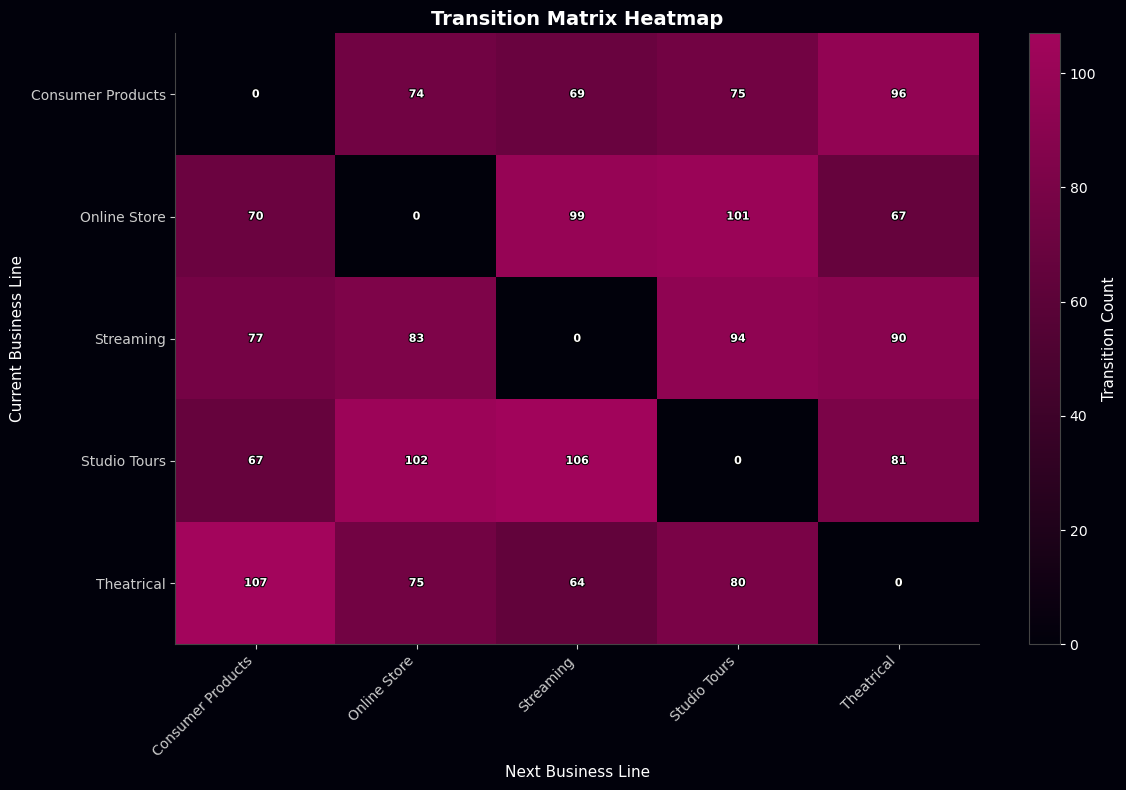

<Figure size 640x480 with 0 Axes>

In [143]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patheffects as pe

transition_matrix = pd.crosstab(
    transitions["Business Line"],
    transitions["next_business_line"]
)

# custom colormap using your theme colors
custom_cmap = LinearSegmentedColormap.from_list(
    "ges_heatmap",
    ['#01010b', '#a3055c']
)

plt.figure(figsize=(12, 8))
ax = plt.gca()

im = ax.imshow(transition_matrix, aspect="auto", cmap=custom_cmap)

ax.set_title("Transition Matrix Heatmap", fontsize=TITLE_SIZE, weight="bold")
ax.set_xlabel("Next Business Line", fontsize=LABEL_SIZE)
ax.set_ylabel("Current Business Line", fontsize=LABEL_SIZE)

ax.set_xticks(range(len(transition_matrix.columns)))
ax.set_xticklabels(
    transition_matrix.columns,
    rotation=45,
    ha="right",
    fontsize=TICK_SIZE
)

ax.set_yticks(range(len(transition_matrix.index)))
ax.set_yticklabels(
    transition_matrix.index,
    fontsize=TICK_SIZE
)

# clearer cell labels with outline
for i in range(transition_matrix.shape[0]):
    for j in range(transition_matrix.shape[1]):
        value = transition_matrix.iloc[i, j]
        txt = ax.text(
            j, i, str(value),
            ha="center", va="center",
            color="white",
            fontsize=8,
            fontweight="bold"
        )
        txt.set_path_effects([
            pe.withStroke(linewidth=1.5, foreground="black")
        ])

cbar = plt.colorbar(im)
cbar.set_label("Transition Count", fontsize=LABEL_SIZE)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.get_yticklabels(), color='white')

plt.tight_layout()
plt.show()

plt.savefig("Visuals/ben_transition_heatmap.png", dpi=300, bbox_inches="tight")

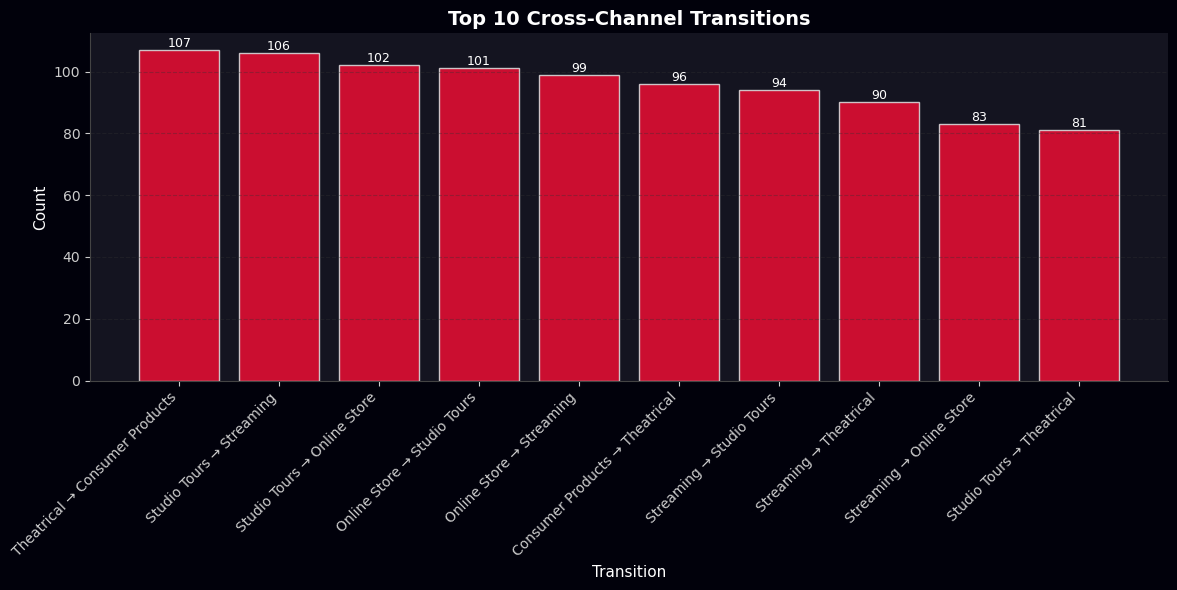

<Figure size 640x480 with 0 Axes>

In [141]:
top_transitions = transition_counts.head(10).copy()
top_transitions["transition_label"] = (
    top_transitions["Business Line"] + " → " + top_transitions["next_business_line"]
)

plt.figure(figsize=(12, 6))

bars = plt.bar(
    top_transitions["transition_label"],
    top_transitions["transition_count"],
    color=PALETTE[2],
    edgecolor=EDGE_COLOR,
    alpha=BAR_ALPHA
)

plt.title("Top 10 Cross-Channel Transitions", fontsize=TITLE_SIZE, weight="bold")
plt.xlabel("Transition", fontsize=LABEL_SIZE)
plt.ylabel("Count", fontsize=LABEL_SIZE)
plt.xticks(rotation=45, ha="right", fontsize=TICK_SIZE)
plt.yticks(fontsize=TICK_SIZE)
plt.grid(axis="y", alpha=GRID_ALPHA)

plt.bar_label(bars, fontsize=BAR_LABEL_SIZE)
plt.tight_layout()
plt.show()

plt.savefig("Visuals/ben_top_channel_transitions.png", dpi=300, bbox_inches="tight")

### Insight: Cross-channel movement is broad rather than dominated by one pathway

The transition matrix suggests that customer movement across GES business lines is fairly distributed, with no single cross-channel path overwhelmingly dominating the others. This indicates that multi-channel engagement does not appear to rely on one primary customer journey. Instead, customers seem to move across the ecosystem through several different channel combinations.

This is useful for the case because it suggests GES should avoid overly narrow assumptions about how customers progress. Rather than focusing on just one transition path, GES may need broader cross-channel marketing and integration strategies that support multiple entry points and multiple follow-on engagement routes.